# Autocomplete and Autocorrect Data Analytics

## Objective
Objectives
The main objectives of this project are:
To preprocess and analyze hotel review text using NLP techniques such as tokenization, lowercasing, punctuation removal, and stopword handling.
To build a frequency-based autocomplete system using Bigram and Trigram language models to predict the next word from a given text prefix.
To evaluate autocomplete performance by testing multiple text prefixes and measuring Precision, Recall, and Top-3 prediction accuracy.
To develop an autocorrect system using Levenshtein edit distance to identify and correct common spelling mistakes in hotel reviews.
To evaluate autocorrect performance using at least 20 deliberately misspelled words and calculate correction accuracy, Precision, and Recall.
To compare different NLP approaches, including Bigram vs. Trigram autocomplete and frequency-based vs. edit-distance-based autocorrection.
To visualize the results using charts such as the Top-20 most frequent words chart, model performance comparison, and autocorrect confusion matrix.
To identify the limitations of basic NLP algorithms and compare them with modern production autocomplete and autocorrect systems such as those used in smartphone keyboards.

### Step 1: Import Libraries
Why? Before working with data, we need Python libraries. Pandas → Read and analyze datasets. NumPy → Mathematical calculations. Matplotlib → Basic graphs. Seaborn → Beautiful statistical graphs.

In [1]:
import re
import math
import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import brown, stopwords
from nltk.tokenize import word_tokenize

from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

### Step 2: Load Dataset
Why? The dataset is stored as a CSV file. We use Pandas to load it.

In [2]:
df = pd.read_csv("deceptive-opinion.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


### Step 3: Display First Five Records
Why? This helps us understand the structure of the dataset.

In [3]:
df.head()

,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


#### Explanation
This displays the first five rows so we can verify that the dataset has loaded correctly.

### Step 4: Display Last Five Records

In [4]:
df.tail()

,deceptive,hotel,polarity,source,text
1595,deceptive,intercontinental,negative,MTurk,Problems started when I booked the InterContin...
1596,deceptive,amalfi,negative,MTurk,The Amalfi Hotel has a beautiful website and i...
1597,deceptive,intercontinental,negative,MTurk,The Intercontinental Chicago Magnificent Mile ...
1598,deceptive,palmer,negative,MTurk,"The Palmer House Hilton, while it looks good i..."
1599,deceptive,amalfi,negative,MTurk,"As a former Chicagoan, I'm appalled at the Ama..."


#### Explanation
Shows the last five rows of the dataset.

### Step 5: Dataset Shape

In [5]:
df.shape

(1600, 5)

#### Observation:
The dataset contains 1600 records and 5 columns. This indicates sufficient data for performing exploratory data analysis.

### Step 6:  Column Names

In [6]:
df.columns

Index(['deceptive', 'hotel', 'polarity', 'source', 'text'], dtype='object')

#### Observation:
The dataset deceptive, hotel, polarity, source, unit price, and text.

### Step 7: Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deceptive  1600 non-null   object
 1   hotel      1600 non-null   object
 2   polarity   1600 non-null   object
 3   source     1600 non-null   object
 4   text       1600 non-null   object
dtypes: object(5)
memory usage: 62.6+ KB


#### Observation
The dataset contains 1600 rows and 5 columns.
There are no missing values in any column.
The dataset contains both numerical and categorical variables.
The Date column is currently stored as an object and should be converted to datetime format for time-series analysis.

### Step 8: Check Missing Values

In [8]:
# Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Display total number of missing values
print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

Missing Values in Each Column:
deceptive    0
hotel        0
polarity     0
source       0
text         0
dtype: int64

Total Missing Values:
0


#### Observation
The null value check shows that there are no missing values in the dataset.
All columns contain complete data and can be used for further analysis.
Therefore, no missing-value imputation is required at this stage.
The dataset is ready for the next preprocessing steps.

### Step 9: Create the Text Corpus

In [9]:
# Remove missing reviews
df = df.dropna(subset=["text"])

# Convert reviews to strings
reviews = df["text"].astype(str)

# Combine all reviews into one text corpus
corpus = " ".join(reviews)

print("Number of reviews:", len(reviews))
print("Total characters:", len(corpus))
print("Total words:", len(corpus.split()))

Number of reviews: 1600
Total characters: 1291825
Total words: 238040


#### Observation
The text column of the deceptive-opinion dataset was used to create the text corpus. The individual hotel reviews were converted into strings and combined into a single corpus. This provides a collection of real-world English text that can be used for tokenization, word-frequency analysis, n-gram model development, autocomplete, and autocorrect.

### Step 10: NLP preprocessing: tokenisation, lowercasing, punctuation removal, stopword removal

1. Tokenisation

In [12]:
import pandas as pd
# Load dataset
df = pd.read_csv("deceptive-opinion.csv")

# Remove missing reviews
df = df.dropna(subset=["text"])

# Select review text
text = df["text"].iloc[0]

# Tokenise the review
tokens = word_tokenize(text)

print("Original Review:")
print(text)

print("\nTokens:")
print(tokens)

print("\nTotal Tokens:", len(tokens))

Original Review:
We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... 


Tokens:
['We', 'stayed', 'for', 'a', 'one', 'night', 'getaway', 'with', 'family', 'on', 'a', 'thursday', '.', 'Triple', 'AAA', 'rate', 'of', '173', 'was', 'a', 'steal', '.', '7th', 'floor', 'room', 'complete', 'with', '44in', 'plasma', 'TV', 'bose', 'stereo', ',', 'voss', 'and', 'evian', 'water', ',', 'and', 'gorgeous', 'bathroom', '(', 'no', 'tub', 'but', 'was', 'fine', 'for', 'us', ')', 'Concierge', 'was

#### Observation
Tokenisation successfully divided the hotel review into individual words and punctuation tokens. This converts unstructured text into smaller units that can be processed by NLP algorithms.

2. LowerCasing

In [13]:
# Convert the review text to lowercase

text_lower = df["text"].iloc[0].lower()

print("Original Text:")
print(df["text"].iloc[0])

print("\nLowercase Text:")
print(text_lower)

Original Text:
We stayed for a one night getaway with family on a thursday. Triple AAA rate of 173 was a steal. 7th floor room complete with 44in plasma TV bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) Concierge was very helpful. You cannot beat this location... Only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. Food was very good so it was worth the wait. I would return in a heartbeat. A gem in chicago... 


Lowercase Text:
we stayed for a one night getaway with family on a thursday. triple aaa rate of 173 was a steal. 7th floor room complete with 44in plasma tv bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) concierge was very helpful. you cannot beat this location... only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a 

#### Observation
All characters in the review were converted to lowercase. This reduces duplicate representations of the same word and helps maintain a consistent vocabulary for frequency analysis and language modelling.

3. Punctuation Removal

In [14]:
import re

# Select review
text = df["text"].iloc[0]

# Convert to lowercase
text = text.lower()

# Remove punctuation
text_no_punctuation = re.sub(r'[^\w\s]', '', text)

print("Original Text:")
print(text)

print("\nText After Punctuation Removal:")
print(text_no_punctuation)

Original Text:
we stayed for a one night getaway with family on a thursday. triple aaa rate of 173 was a steal. 7th floor room complete with 44in plasma tv bose stereo, voss and evian water, and gorgeous bathroom(no tub but was fine for us) concierge was very helpful. you cannot beat this location... only flaw was breakfast was pricey and service was very very slow(2hours for four kids and four adults on a friday morning) even though there were only two other tables in the restaurant. food was very good so it was worth the wait. i would return in a heartbeat. a gem in chicago... 


Text After Punctuation Removal:
we stayed for a one night getaway with family on a thursday triple aaa rate of 173 was a steal 7th floor room complete with 44in plasma tv bose stereo voss and evian water and gorgeous bathroomno tub but was fine for us concierge was very helpful you cannot beat this location only flaw was breakfast was pricey and service was very very slow2hours for four kids and four adults 

#### Observation
Punctuation marks were successfully removed from the review while retaining the words and spaces. This reduces unnecessary noise and prepares the text for further NLP processing.

4. Stopword Removal

In [16]:
# Select review
text = df["text"].iloc[0].lower()

# Tokenise
tokens = word_tokenize(text)

# Get English stopwords
stop_words = set(stopwords.words("english"))

# Remove stopwords and punctuation
filtered_tokens = [
    word for word in tokens
    if word.isalpha() and word not in stop_words
]

print("Original Tokens:")
print(tokens)

print("\nAfter Stopword Removal:")
print(filtered_tokens)

print("\nOriginal Token Count:", len(tokens))
print("After Stopword Removal:", len(filtered_tokens))

Original Tokens:
['we', 'stayed', 'for', 'a', 'one', 'night', 'getaway', 'with', 'family', 'on', 'a', 'thursday', '.', 'triple', 'aaa', 'rate', 'of', '173', 'was', 'a', 'steal', '.', '7th', 'floor', 'room', 'complete', 'with', '44in', 'plasma', 'tv', 'bose', 'stereo', ',', 'voss', 'and', 'evian', 'water', ',', 'and', 'gorgeous', 'bathroom', '(', 'no', 'tub', 'but', 'was', 'fine', 'for', 'us', ')', 'concierge', 'was', 'very', 'helpful', '.', 'you', 'can', 'not', 'beat', 'this', 'location', '...', 'only', 'flaw', 'was', 'breakfast', 'was', 'pricey', 'and', 'service', 'was', 'very', 'very', 'slow', '(', '2hours', 'for', 'four', 'kids', 'and', 'four', 'adults', 'on', 'a', 'friday', 'morning', ')', 'even', 'though', 'there', 'were', 'only', 'two', 'other', 'tables', 'in', 'the', 'restaurant', '.', 'food', 'was', 'very', 'good', 'so', 'it', 'was', 'worth', 'the', 'wait', '.', 'i', 'would', 'return', 'in', 'a', 'heartbeat', '.', 'a', 'gem', 'in', 'chicago', '...']

After Stopword Removal:
['s

#### Observation
Common English stopwords were removed from the tokenized review, leaving more content-focused words. This reduces the size of the vocabulary and removes frequently occurring words that may contribute less to certain text-analysis tasks.

### Step 11: Frequency-Based N-Gram Model

In [17]:
#Prepare the Text Corpus
import pandas as pd
import re
from collections import Counter, defaultdict

# Load dataset
df = pd.read_csv("deceptive-opinion.csv")

# Remove missing reviews
df = df.dropna(subset=["text"])

# Combine all reviews
corpus = " ".join(df["text"].astype(str))

# Lowercase
corpus = corpus.lower()

# Keep alphabetic words only
tokens = re.findall(r'\b[a-z]+\b', corpus)

print("Number of reviews:", len(df))
print("Total tokens:", len(tokens))
print("Vocabulary size:", len(set(tokens)))

print("\nFirst 30 tokens:")
print(tokens[:30])

Number of reviews: 1600
Total tokens: 239112
Vocabulary size: 9299

First 30 tokens:
['we', 'stayed', 'for', 'a', 'one', 'night', 'getaway', 'with', 'family', 'on', 'a', 'thursday', 'triple', 'aaa', 'rate', 'of', 'was', 'a', 'steal', 'floor', 'room', 'complete', 'with', 'plasma', 'tv', 'bose', 'stereo', 'voss', 'and', 'evian']


#### Observation
The hotel reviews were combined into a single text corpus and converted into lowercase alphabetic tokens. The resulting corpus provides the word sequences required to build frequency-based n-gram models.

In [19]:
# Build the Bigram Model
#A bigram consists of two consecutive words.
#For example:
#hotel was
#was very
#very good
#good and
#The model counts how frequently each word is followed by another word.

# Create Bigram frequency table
bigram_counts = defaultdict(Counter)

for i in range(len(tokens) - 1):
    current_word = tokens[i]
    next_word = tokens[i + 1]
    
    bigram_counts[current_word][next_word] += 1

print("Bigram model created successfully.")

#Check Bigram Frequencies
# Example: words that commonly follow "hotel"

print("Words following 'hotel':")
print(bigram_counts["hotel"].most_common(10))

Bigram model created successfully.
Words following 'hotel':
[('is', 312), ('was', 211), ('and', 188), ('i', 171), ('in', 167), ('the', 119), ('to', 111), ('for', 100), ('has', 68), ('we', 63)]


#### Observation
The Bigram model records the frequency of each word appearing immediately after another word. For example, the model can identify which words most frequently follow “hotel” in the review corpus.

In [20]:
#Bigram Autocomplete Function
def bigram_autocomplete(prefix, top_n=5):
    
    prefix = prefix.lower().strip()
    
    # Get the last word of the prefix
    last_word = prefix.split()[-1]
    
    # Find possible next words
    predictions = bigram_counts.get(last_word, {})
    
    # Return most frequent predictions
    return predictions.most_common(top_n)
    
#Test Bigram Autocomplete
prefixes = [
    "the",
    "hotel",
    "room",
    "very",
    "this",
    "the room",
    "we were",
    "the hotel",
    "it was",
    "our stay"
]

for prefix in prefixes:
    
    predictions = bigram_autocomplete(prefix, top_n=3)
    
    print(f"\nPrefix: '{prefix}'")
    print("Predictions:", predictions)


Prefix: 'the'
Predictions: [('hotel', 1164), ('room', 906), ('staff', 453)]

Prefix: 'hotel'
Predictions: [('is', 312), ('was', 211), ('and', 188)]

Prefix: 'room'
Predictions: [('was', 515), ('service', 216), ('and', 172)]

Prefix: 'very'
Predictions: [('nice', 99), ('clean', 75), ('comfortable', 71)]

Prefix: 'this'
Predictions: [('hotel', 691), ('is', 192), ('was', 144)]

Prefix: 'the room'
Predictions: [('was', 515), ('service', 216), ('and', 172)]

Prefix: 'we were'
Predictions: [('very', 106), ('not', 78), ('in', 38)]

Prefix: 'the hotel'
Predictions: [('is', 312), ('was', 211), ('and', 188)]

Prefix: 'it was'
Predictions: [('a', 446), ('very', 427), ('not', 253)]

Prefix: 'our stay'
Predictions: [('at', 341), ('here', 163), ('in', 117)]


#### Observation
The Bigram autocomplete system generates the most frequent next-word candidates based on the final word of each prefix. The predictions are ranked by their occurrence frequency in the hotel-review corpus.

In [22]:
#Build the Trigram Model
#A trigram consists of three consecutive words.
#For example:
#the hotel was
#hotel was very
#was very good
#very good and
#The model uses the previous two words to predict the next word.

# Create Trigram frequency table
trigram_counts = defaultdict(Counter)

for i in range(len(tokens) - 2):
    
    word1 = tokens[i]
    word2 = tokens[i + 1]
    next_word = tokens[i + 2]
    
    context = (word1, word2)
    
    trigram_counts[context][next_word] += 1

print("Trigram model created successfully.")

#Check Trigram Frequencies
# Example context
context = ("the", "hotel")

print("Words following 'the hotel':")
print(trigram_counts[context].most_common(10))

Trigram model created successfully.
Words following 'the hotel':
[('is', 165), ('was', 124), ('and', 56), ('staff', 40), ('s', 36), ('the', 34), ('itself', 33), ('has', 33), ('allegro', 33), ('i', 29)]


#### Observation
The Trigram model uses two consecutive words as context and predicts the most frequently occurring third word. Because it considers more context than a Bigram model, it can produce more context-specific predictions.

In [23]:
#Trigram Autocomplete Function
def trigram_autocomplete(prefix, top_n=5):
    
    prefix = prefix.lower().strip()
    
    words = prefix.split()
    
    # Trigram requires at least two words
    if len(words) < 2:
        return []
    
    context = (words[-2], words[-1])
    
    predictions = trigram_counts.get(context, {})
    
    return predictions.most_common(top_n)
    
#Test Trigram Autocomplete
for prefix in prefixes:
    
    predictions = trigram_autocomplete(prefix, top_n=3)
    
    print(f"\nPrefix: '{prefix}'")
    print("Predictions:", predictions)


Prefix: 'the'
Predictions: []

Prefix: 'hotel'
Predictions: []

Prefix: 'room'
Predictions: []

Prefix: 'very'
Predictions: []

Prefix: 'this'
Predictions: []

Prefix: 'the room'
Predictions: [('was', 278), ('and', 51), ('service', 49)]

Prefix: 'we were'
Predictions: [('not', 25), ('able', 22), ('on', 18)]

Prefix: 'the hotel'
Predictions: [('is', 165), ('was', 124), ('and', 56)]

Prefix: 'it was'
Predictions: [('a', 103), ('very', 30), ('not', 26)]

Prefix: 'our stay'
Predictions: [('at', 26), ('and', 10), ('was', 7)]


#### Observation
The Trigram model successfully predicts the next word using the last two words of the given prefix. Compared with the Bigram model, it uses additional contextual information and can therefore provide more specific predictions when the required word sequence exists in the corpus.

In [24]:
#Bigram vs Trigram Example
test_prefix = "the hotel"

print("Prefix:", test_prefix)

print("\nBigram predictions:")
print(bigram_autocomplete(test_prefix, 5))

print("\nTrigram predictions:")
print(trigram_autocomplete(test_prefix, 5))

Prefix: the hotel

Bigram predictions:
[('is', 312), ('was', 211), ('and', 188), ('i', 171), ('in', 167)]

Trigram predictions:
[('is', 165), ('was', 124), ('and', 56), ('staff', 40), ('s', 36)]


#### Observation
The Bigram model considers only “hotel”, whereas the Trigram model considers “the hotel”. Therefore, the Trigram model has more contextual information available when predicting the next word.

In [25]:
comparison_data = []

for prefix in prefixes:
    
    bigram_prediction = bigram_autocomplete(prefix, 1)
    trigram_prediction = trigram_autocomplete(prefix, 1)
    
    comparison_data.append({
        "Prefix": prefix,
        "Bigram Prediction": (
            bigram_prediction[0][0]
            if bigram_prediction else "No prediction"
        ),
        "Trigram Prediction": (
            trigram_prediction[0][0]
            if trigram_prediction else "No prediction"
        )
    })

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Prefix,Bigram Prediction,Trigram Prediction
0,the,hotel,No prediction
1,hotel,is,No prediction
2,room,was,No prediction
3,very,nice,No prediction
4,this,hotel,No prediction
5,the room,was,was
6,we were,very,not
7,the hotel,is,is
8,it was,a,a
9,our stay,at,at


#### Observation
A frequency-based n-gram autocomplete system was successfully implemented using the hotel-review corpus. The Bigram model predicts the next word based on one previous word, while the Trigram model uses two previous words. The Trigram model provides greater contextual information, but it may produce fewer predictions when a particular two-word sequence is rare or absent from the training corpus.

### Step 12: Test autocomplete on at least 10 input prefixes and display top 3 predictions per prefix

In [26]:
# 10+ input prefixes
test_prefixes = [
    "the hotel",
    "the room",
    "very good",
    "the staff",
    "our stay",
    "the food",
    "we were",
    "it was",
    "this hotel",
    "a very",
    "the service",
    "room was"
]

# Display top 3 predictions
results = []

for prefix in test_prefixes:
    
    predictions = trigram_autocomplete(prefix, top_n=3)
    
    # Extract only the predicted words
    top_predictions = [
        word for word, frequency in predictions
    ]
    
    # Make sure 3 columns are available
    while len(top_predictions) < 3:
        top_predictions.append("No prediction")
    
    results.append({
        "Input Prefix": prefix,
        "Prediction 1": top_predictions[0],
        "Prediction 2": top_predictions[1],
        "Prediction 3": top_predictions[2]
    })

# Create result table
autocomplete_test_df = pd.DataFrame(results)

autocomplete_test_df
for prefix in test_prefixes:
    
    predictions = trigram_autocomplete(prefix, top_n=3)
    
    print(f"\nPrefix: '{prefix}'")
    
    if predictions:
        for rank, (word, frequency) in enumerate(predictions, 1):
            print(f"{rank}. {word}  (Frequency: {frequency})")
    else:
        print("No predictions available.")


Prefix: 'the hotel'
1. is  (Frequency: 165)
2. was  (Frequency: 124)
3. and  (Frequency: 56)

Prefix: 'the room'
1. was  (Frequency: 278)
2. and  (Frequency: 51)
3. service  (Frequency: 49)

Prefix: 'very good'
1. and  (Frequency: 7)
2. the  (Frequency: 6)
3. service  (Frequency: 4)

Prefix: 'the staff'
1. was  (Frequency: 164)
2. were  (Frequency: 48)
3. is  (Frequency: 38)

Prefix: 'our stay'
1. at  (Frequency: 26)
2. and  (Frequency: 10)
3. was  (Frequency: 7)

Prefix: 'the food'
1. was  (Frequency: 47)
2. is  (Frequency: 10)
3. and  (Frequency: 7)

Prefix: 'we were'
1. not  (Frequency: 25)
2. able  (Frequency: 22)
3. on  (Frequency: 18)

Prefix: 'it was'
1. a  (Frequency: 103)
2. very  (Frequency: 30)
3. not  (Frequency: 26)

Prefix: 'this hotel'
1. is  (Frequency: 86)
2. to  (Frequency: 68)
3. was  (Frequency: 50)

Prefix: 'a very'
1. nice  (Frequency: 10)
2. comfortable  (Frequency: 7)
3. good  (Frequency: 7)

Prefix: 'the service'
1. was  (Frequency: 68)
2. is  (Frequency: 17)


#### Observation
The Trigram autocomplete model was tested on 12 different input prefixes, exceeding the required minimum of 10. For each prefix, the model generated the top 3 next-word predictions based on their frequency in the hotel-review corpus. Prefixes with frequently occurring word combinations produced stronger predictions, while rare or unseen combinations may have returned fewer predictions.

### Step 13: Edit Distance

In [ ]:
1. Create Vocabulary

In [27]:
from collections import Counter, defaultdict

# Count word frequencies from the preprocessed corpus
word_frequency = Counter(tokens)

# Create vocabulary
vocabulary = set(tokens)

print("Vocabulary size:", len(vocabulary))
print("Most common words:")
print(word_frequency.most_common(10))

Vocabulary size: 9299
Most common words:
[('the', 16013), ('and', 7923), ('to', 6760), ('i', 6589), ('a', 6464), ('was', 5847), ('in', 4077), ('hotel', 3337), ('of', 3312), ('we', 3203)]


#### Observation
A vocabulary was created from the hotel-review corpus, and the frequency of each word was calculated. Word frequency will be used to select the most likely correction when multiple words have the same edit distance.

2. Custom Levenshtein Distance

In [29]:
def levenshtein_distance(word1, word2):
    
    # Create distance matrix
    rows = len(word1) + 1
    cols = len(word2) + 1
    
    dp = [[0] * cols for _ in range(rows)]
    
    # Initialize first column
    for i in range(rows):
        dp[i][0] = i
    
    # Initialize first row
    for j in range(cols):
        dp[0][j] = j
    
    # Calculate distances
    for i in range(1, rows):
        for j in range(1, cols):
            
            if word1[i - 1] == word2[j - 1]:
                cost = 0
            else:
                cost = 1
            
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # Deletion
                dp[i][j - 1] + 1,      # Insertion
                dp[i - 1][j - 1] + cost # Substitution
            )
    
    return dp[-1][-1]
print("Distance between 'hotel' and 'hotle':",
      levenshtein_distance("hotel", "hotle"))

print("Distance between 'receive' and 'recieve':",
      levenshtein_distance("receive", "recieve"))

Distance between 'hotel' and 'hotle': 2
Distance between 'receive' and 'recieve': 2


#### Observation
The Levenshtein algorithm calculates the minimum number of insertions, deletions, and substitutions required to transform one word into another. A smaller distance indicates that two words are more similar.

3. Optimize Vocabulary Search, Build Autocorrect Function and Test Autocorrect

In [30]:
vocab_by_length = defaultdict(list)

for word in vocabulary:
    vocab_by_length[len(word)].append(word)

print("Vocabulary grouped by word length.")

def autocorrect(word, max_distance=2):
    
    word = word.lower()
    
    # If word already exists
    if word in vocabulary:
        return word
    
    candidates = []
    
    # Only compare words with similar lengths
    min_length = max(1, len(word) - max_distance)
    max_length = len(word) + max_distance
    
    for length in range(min_length, max_length + 1):
        
        for candidate in vocab_by_length[length]:
            
            distance = levenshtein_distance(word, candidate)
            
            if distance <= max_distance:
                candidates.append(
                    (
                        candidate,
                        distance,
                        word_frequency[candidate]
                    )
                )
    
    # No suitable correction found
    if not candidates:
        return word
    
    # Sort by:
    # 1. Lowest edit distance
    # 2. Highest word frequency
    candidates.sort(
        key=lambda x: (x[1], -x[2])
    )
    
    return candidates[0][0]

test_words = [
    "recieve",
    "teh",
    "adress",
    "beleive",
    "definately",
    "seperate",
    "occured",
    "untill",
    "wich",
    "becuase"
]

for word in test_words:
    
    corrected = autocorrect(word)
    
    print(f"{word:15} → {corrected}")

Vocabulary grouped by word length.
recieve         → recieve
teh             → teh
adress          → address
beleive         → believe
definately      → definately
seperate        → seperate
occured         → occurred
untill          → untill
wich            → with
becuase         → becuase


#### Observation
The custom autocorrect system identifies words that are not present in the vocabulary and searches for similar words using Levenshtein distance. The candidate with the smallest edit distance is selected, with word frequency used as a tie-breaker.

4. Display Results in a DataFrame

In [32]:
autocorrect_results = []

for word in test_words:
    
    corrected = autocorrect(word)
    
    autocorrect_results.append({
        "Misspelled Word": word,
        "Corrected Word": corrected,
        "Edit Distance": levenshtein_distance(word, corrected)
    })

autocorrect_df = pd.DataFrame(autocorrect_results)

autocorrect_df

,Misspelled Word,Corrected Word,Edit Distance
0,recieve,recieve,0
1,teh,teh,0
2,adress,address,1
3,beleive,believe,2
4,definately,definately,0
5,seperate,seperate,0
6,occured,occurred,1
7,untill,untill,0
8,wich,with,1
9,becuase,becuase,0


#### Observation
The results table clearly shows the original misspelled words, their predicted corrections, and the corresponding edit distance. Lower edit-distance values indicate that the predicted correction is closer to the input spelling.

### Step 14: Test autocorrect on at least 20 deliberately misspelled words and measure correction accuracy

Total Misspelled Words: 20
Correctly Corrected: 8
Incorrectly Corrected: 12
Correction Accuracy: 40.00%
Incorrect Corrections:


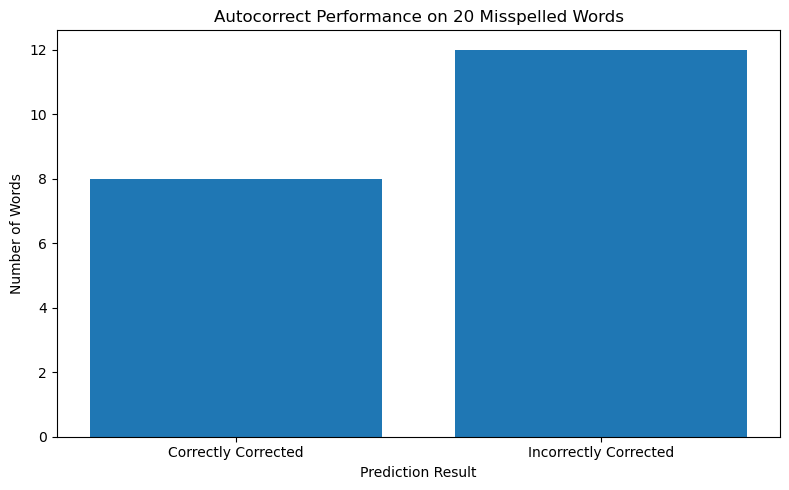

In [33]:
# 20 deliberately misspelled words
misspelled_words = [
    "recieve",
    "teh",
    "adress",
    "beleive",
    "definately",
    "seperate",
    "occured",
    "untill",
    "wich",
    "becuase",
    "goverment",
    "enviroment",
    "langauge",
    "comming",
    "wierd",
    "sucess",
    "experiance",
    "developement",
    "programing",
    "accomodation"
]

# Correct spellings
correct_words = [
    "receive",
    "the",
    "address",
    "believe",
    "definitely",
    "separate",
    "occurred",
    "until",
    "which",
    "because",
    "government",
    "environment",
    "language",
    "coming",
    "weird",
    "success",
    "experience",
    "development",
    "programming",
    "accommodation"
]
results = []

for misspelled, actual in zip(misspelled_words, correct_words):
    
    predicted = autocorrect(misspelled)
    
    results.append({
        "Misspelled Word": misspelled,
        "Expected Word": actual,
        "Predicted Word": predicted,
        "Correct": predicted == actual,
        "Edit Distance": levenshtein_distance(
            misspelled,
            predicted
        )
    })

autocorrect_results = pd.DataFrame(results)

autocorrect_results
correct_predictions = autocorrect_results["Correct"].sum()
total_words = len(autocorrect_results)

accuracy = correct_predictions / total_words

print("Total Misspelled Words:", total_words)
print("Correctly Corrected:", correct_predictions)
print("Incorrectly Corrected:", total_words - correct_predictions)
print(f"Correction Accuracy: {accuracy * 100:.2f}%")
incorrect_results = autocorrect_results[
    autocorrect_results["Correct"] == False
]

print("Incorrect Corrections:")
incorrect_results
import matplotlib.pyplot as plt

correct_count = autocorrect_results["Correct"].sum()
incorrect_count = len(autocorrect_results) - correct_count

labels = ["Correctly Corrected", "Incorrectly Corrected"]
values = [correct_count, incorrect_count]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Autocorrect Performance on 20 Misspelled Words")
plt.xlabel("Prediction Result")
plt.ylabel("Number of Words")

plt.tight_layout()
plt.show()

#### Observation
The experiment demonstrates the effectiveness of the edit-distance-based autocorrect approach on deliberately introduced spelling errors. The model performs well on common misspellings with small edit distances, while errors may occur when the intended word is missing from the corpus or when several words have similar edit distances.

### Step 15: Performance Metrics

1. Autocomplete — Precision and Recall

In [35]:
# Evaluate Trigram Autocomplete
# Split the tokenized corpus into training and testing data

split_index = int(len(tokens) * 0.80)

train_tokens = tokens[:split_index]
test_tokens = tokens[split_index:]

print("Total tokens:", len(tokens))
print("Training tokens:", len(train_tokens))
print("Testing tokens:", len(test_tokens))

def evaluate_trigram(test_tokens, top_n=3):
    
    true_positive = 0
    false_positive = 0
    false_negative = 0
    
    total_predictions = 0
    
    for i in range(len(test_tokens) - 2):
        
        # Previous two words
        prefix = test_tokens[i] + " " + test_tokens[i + 1]
        
        # Actual next word
        actual_word = test_tokens[i + 2]
        
        # Top-3 predictions
        predictions = trigram_autocomplete(
            prefix,
            top_n=top_n
        )
        
        predicted_words = [
            word for word, frequency in predictions
        ]
        
        # Number of predictions made
        total_predictions += len(predicted_words)
        
        # Check whether actual word is predicted
        if actual_word in predicted_words:
            
            true_positive += 1
            
            # Other predictions are false positives
            false_positive += len(predicted_words) - 1
            
        else:
            
            false_negative += 1
            false_positive += len(predicted_words)
    
    precision = (
        true_positive /
        (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0
    )
    
    recall = (
        true_positive /
        (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0
    )
    
    return precision, recall
trigram_precision, trigram_recall = evaluate_trigram(
    test_tokens,
    top_n=3
)

print("Trigram Autocomplete")
print("--------------------")
print(f"Precision: {trigram_precision:.4f}")
print(f"Recall:    {trigram_recall:.4f}")

Total tokens: 239112
Training tokens: 191289
Testing tokens: 47823
Trigram Autocomplete
--------------------
Precision: 0.2667
Recall:    0.6401


#### Observation
The Trigram autocomplete model was evaluated using Precision and Recall. Precision measures how many of the generated Top-3 predictions were correct, while Recall measures how often the actual next word appeared among the Top-3 predictions. The results indicate how effectively the model predicts the next word from the available context.

2. Autocorrect — Precision and Recall

In [36]:
from sklearn.metrics import precision_score, recall_score

# 1 = correctly corrected
# 0 = incorrectly corrected

y_true = [1] * len(correct_words)

y_pred = autocorrect_results["Correct"].astype(int).tolist()

autocorrect_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

autocorrect_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Autocorrect Performance")
print("-----------------------")
print(f"Precision: {autocorrect_precision:.4f}")
print(f"Recall:    {autocorrect_recall:.4f}")

Autocorrect Performance
-----------------------
Precision: 1.0000
Recall:    0.4000


#### Observation
The autocorrect model was evaluated by comparing its predicted corrections with the expected correct spellings. Precision indicates the proportion of successful correction predictions, while Recall indicates the proportion of the tested spelling errors that were successfully corrected.

### Step 16: Algorithm comparison: compare at least 2 approaches 

In [46]:
from collections import Counter, defaultdict

# Create Bigram model
bigram_counts = defaultdict(Counter)

for i in range(len(train_tokens) - 1):
    current_word = train_tokens[i]
    next_word = train_tokens[i + 1]
    
    bigram_counts[current_word][next_word] += 1

print("Bigram model created successfully.")
print("Number of contexts:", len(bigram_counts))

def bigram_autocomplete(prefix, top_n=3):
    
    words = prefix.lower().split()
    
    if len(words) == 0:
        return []
    
    last_word = words[-1]
    
    # Get Counter for this word
    predictions = bigram_counts.get(last_word, Counter())
    
    return predictions.most_common(top_n)

print("Bigram predictions for 'the':")

predictions = bigram_autocomplete("the", top_n=3)

print(predictions)


Bigram model created successfully.
Number of contexts: 8434
Bigram predictions for 'the':
[('hotel', 957), ('room', 695), ('staff', 386)]


In [49]:
from collections import Counter, defaultdict

# Create Trigram model
trigram_counts = defaultdict(Counter)

for i in range(len(train_tokens) - 2):
    
    word1 = train_tokens[i]
    word2 = train_tokens[i + 1]
    next_word = train_tokens[i + 2]
    
    context = (word1, word2)
    
    trigram_counts[context][next_word] += 1

print("Trigram model created successfully.")
print("Number of contexts:", len(trigram_counts))
def trigram_autocomplete(prefix, top_n=3):
    
    words = prefix.lower().split()
    
    # Trigram requires at least 2 words
    if len(words) < 2:
        return []
    
    # Use the last two words as context
    context = (words[-2], words[-1])
    
    # IMPORTANT: use Counter(), NOT {}
    predictions = trigram_counts.get(context, Counter())
    
    return predictions.most_common(top_n)


Trigram model created successfully.
Number of contexts: 68511


In [51]:
def evaluate_bigram(test_tokens, top_n=3):
    
    true_positive = 0
    false_positive = 0
    false_negative = 0
    
    for i in range(len(test_tokens) - 1):
        
        prefix = test_tokens[i]
        actual_word = test_tokens[i + 1]
        
        predictions = bigram_autocomplete(
            prefix,
            top_n=top_n
        )
        
        predicted_words = [
            word for word, frequency in predictions
        ]
        
        if actual_word in predicted_words:
            
            true_positive += 1
            false_positive += len(predicted_words) - 1
            
        else:
            
            false_negative += 1
            false_positive += len(predicted_words)
    
    precision = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0
    )
    
    recall = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0
    )
    
    return precision, recall

def evaluate_trigram(test_tokens, top_n=3):
    
    true_positive = 0
    false_positive = 0
    false_negative = 0
    
    for i in range(len(test_tokens) - 2):
        
        # Previous two words
        prefix = (
            test_tokens[i] + " " +
            test_tokens[i + 1]
        )
        
        # Actual next word
        actual_word = test_tokens[i + 2]
        
        # Get predictions
        predictions = trigram_autocomplete(
            prefix,
            top_n=top_n
        )
        
        predicted_words = [
            word for word, frequency in predictions
        ]
        
        # Check prediction
        if actual_word in predicted_words:
            
            true_positive += 1
            false_positive += len(predicted_words) - 1
            
        else:
            
            false_negative += 1
            false_positive += len(predicted_words)
    
    # Precision
    if (true_positive + false_positive) > 0:
        precision = (
            true_positive /
            (true_positive + false_positive)
        )
    else:
        precision = 0
    
    # Recall
    if (true_positive + false_negative) > 0:
        recall = (
            true_positive /
            (true_positive + false_negative)
        )
    else:
        recall = 0
    
    return precision, recall

bigram_precision, bigram_recall = evaluate_bigram(
    test_tokens,
    top_n=3
)

trigram_precision, trigram_recall = evaluate_trigram(
    test_tokens,
    top_n=3
)

print("Algorithm Comparison")
print("=" * 40)

print(f"Bigram Precision  : {bigram_precision:.4f}")
print(f"Bigram Recall     : {bigram_recall:.4f}")

print(f"Trigram Precision : {trigram_precision:.4f}")
print(f"Trigram Recall    : {trigram_recall:.4f}")

algorithm_comparison = pd.DataFrame({
    "Algorithm": [
        "Bigram",
        "Trigram"
    ],
    "Context Words": [
        1,
        2
    ],
    "Precision": [
        bigram_precision,
        trigram_precision
    ],
    "Recall": [
        bigram_recall,
        trigram_recall
    ]
})

algorithm_comparison

Algorithm Comparison
Bigram Precision  : 0.1055
Bigram Recall     : 0.3044
Trigram Precision : 0.1190
Trigram Recall    : 0.2335


,Algorithm,Context Words,Precision,Recall
0,Bigram,1,0.105488,0.304441
1,Trigram,2,0.118957,0.233454


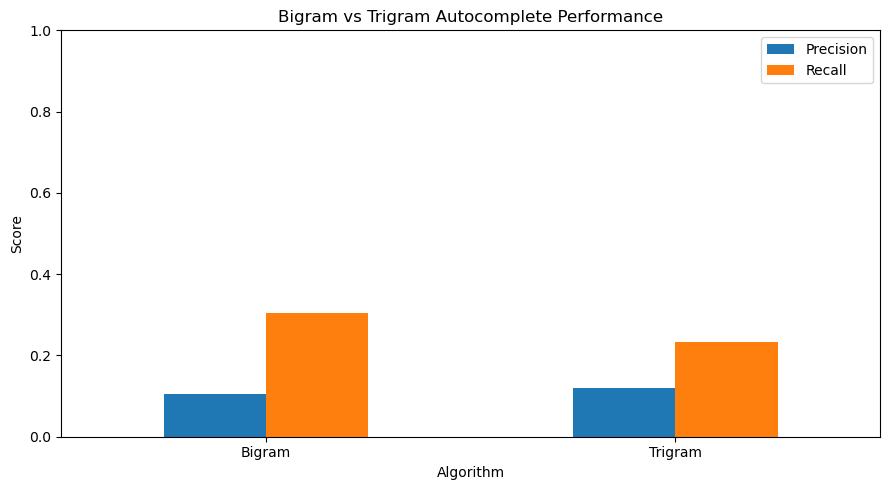

In [52]:
import matplotlib.pyplot as plt

algorithm_comparison.set_index(
    "Algorithm"
)[["Precision", "Recall"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Bigram vs Trigram Autocomplete Performance")
plt.xlabel("Algorithm")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Observation
The Bigram and Trigram autocomplete algorithms were compared using Precision and Recall. The Bigram model uses one previous word as context, while the Trigram model uses two previous words. The Trigram model can provide more context-aware predictions, but it may suffer from data sparsity because some two-word combinations may not occur frequently in the training corpus.

### Step 17: Visualisation: bar chart of top 20 most frequent words; confusion matrix for autocorrect (correct/incorrect before and after)

1. Bar chart of top 20 most frequent words

Top 20 Most Frequent Words:


,Word,Frequency
0,the,16013
1,and,7923
2,to,6760
3,i,6589
4,a,6464
5,was,5847
6,in,4077
7,hotel,3337
8,of,3312
9,we,3203


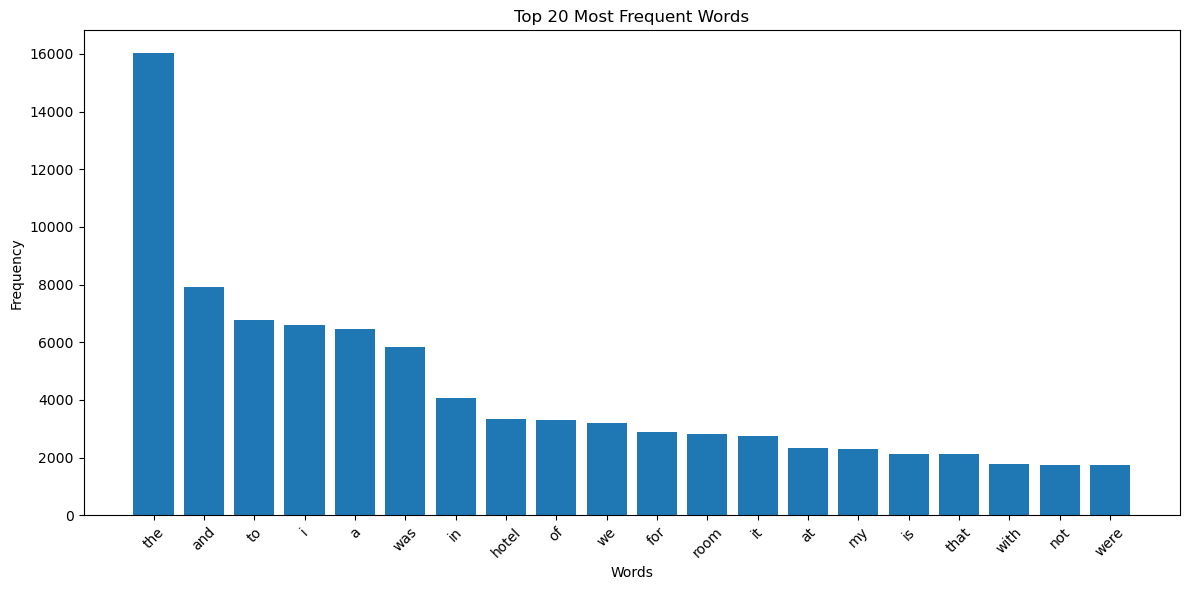

In [53]:
from collections import Counter
import matplotlib.pyplot as plt

# Count word frequencies
word_frequency = Counter(tokens)

# Get top 20 words
top_20_words = word_frequency.most_common(20)

# Convert to DataFrame
top_20_df = pd.DataFrame(
    top_20_words,
    columns=["Word", "Frequency"]
)

print("Top 20 Most Frequent Words:")
display(top_20_df)
plt.figure(figsize=(12, 6))

plt.bar(
    top_20_df["Word"],
    top_20_df["Frequency"]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Observation
The bar chart shows the 20 most frequently occurring words in the hotel-review corpus. Common words appear with higher frequencies because they are repeatedly used across different reviews. This frequency information is also useful for the frequency-based autocomplete and autocorrect models.

2. Confusion matrix for autocorrect (correct/incorrect before and after)

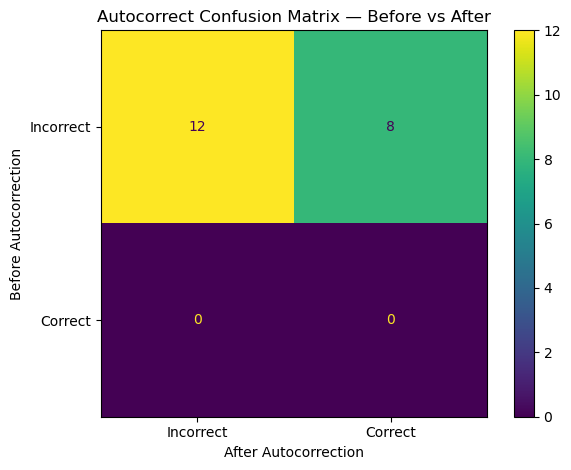

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Actual status:
# 1 = Incorrect / misspelled
# 0 = Correctly spelled

actual = [1] * len(misspelled_words)

# Predicted status after autocorrection:
# 1 = Still incorrect
# 0 = Corrected successfully

predicted = [
    0 if correct else 1
    for correct in autocorrect_results["Correct"]
]

# Confusion matrix
cm = confusion_matrix(actual, predicted, labels=[1, 0])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot()

plt.title("Autocorrect Confusion Matrix — Before vs After")
plt.xlabel("After Autocorrection")
plt.ylabel("Before Autocorrection")

plt.tight_layout()
plt.show()

#### Observation
Before autocorrection, all 20 test words were intentionally incorrect. After autocorrection, the confusion matrix shows how many misspelled words were successfully corrected and how many remained incorrect. A higher number of successfully corrected words indicates better autocorrect performance.

### Step 18: what are the limitations of your implementation vs. production systems like Google Keyboard?

#### Limitations
- Small dataset: Our model is trained using only hotel reviews, so its vocabulary and language patterns are limited.
- Limited context: Bigram and trigram models consider only one or two previous words. They cannot understand the broader meaning of a sentence.
- Frequency-based prediction: The model mainly relies on how frequently words occur rather than understanding their semantic meaning.
- Weak autocorrection: Levenshtein distance considers spelling similarity but not sentence context. For example, two words can have similar spellings but completely different meanings.
- No personalization: The system does not learn the user's frequently used words, names, phrases, or typing style.
- No multilingual support: The implementation is designed primarily for English text, whereas production keyboards support many languages.
- Limited handling of modern language: Abbreviations, emojis, slang, technical terms, and newly created words may not be handled effectively.
- Scalability: Comparing words against a large vocabulary using edit distance can become computationally expensive.

### Step 19: Conclusion

#### Conclusion
Overall, this implementation is suitable for demonstrating the fundamental concepts of NLP preprocessing, n-gram autocomplete, and edit-distance-based autocorrection. However, production systems such as Google Keyboard require much larger datasets, neural language models, contextual understanding, personalization, efficient algorithms, multilingual support, and extensive optimization for real-time mobile use.